# Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.pandas.set_option('display.max_columns', None)

df = pd.read_csv('EasyVisa.csv')

In [2]:
print(df.shape)

(25480, 12)


# Data Cleaning

#### Handling Missing Values

In [3]:
missing_values = df.isnull().sum()
print(missing_values)

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [5]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [6]:
#Handling Duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [7]:
df.drop(columns=['case_id'], inplace=True)

In [8]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [9]:
from datetime import date

todays_date = date.today()
current_year = todays_date.year

In [10]:
# Age of company
df['company_age'] = current_year - df['yr_of_estab']
df.drop(columns=['yr_of_estab'], inplace=True)
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,21


### Type of Features


#### Numerical Features & Categorical Features

In [11]:
numeric_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']

In [12]:
print('Number of Numerical Columns:', len(numeric_cols))
print('Number of Categorical Columns:', len(categorical_cols))

Number of Numerical Columns: 3
Number of Categorical Columns: 8


### Discreet and Continuous Features

In [13]:
discreet_cols = [col for col in numeric_cols if df[col].nunique() < 25]
continuous_cols = [col for col in numeric_cols if df[col].nunique() >= 25]

print('Number of Discreet Columns:', len(discreet_cols))
print('Number of Continuous Columns:', len(continuous_cols))    

Number of Discreet Columns: 0
Number of Continuous Columns: 3


### Splitting into X and Y

In [14]:
X = df.drop(columns=['case_status'], axis=1)
y = df['case_status']

In [15]:
y.head()

0       Denied
1    Certified
2       Denied
3       Denied
4    Certified
Name: case_status, dtype: object

In [16]:
#Encoding Target variable
y = y.map({'Denied': 0, 'Certified': 1})

In [17]:
y

0        0
1        1
2        0
3        0
4        1
        ..
25475    1
25476    1
25477    1
25478    1
25479    1
Name: case_status, Length: 25480, dtype: int64

### Feature Transformation

In [18]:
#check skewness 
X[continuous_cols].skew(axis = 0, skipna = True)

no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

- Positively skewed: no+of_employees, company_age. <br>
- We can handle outliers and then check the skewness.


## Applying Power Transformer to check if it can reduce the outliers

In [19]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method = 'yeo-johnson')
transform_features = ['company_age', 'no_of_employees']
X_copy = pt.fit_transform(X[transform_features])
X_copy = pd.DataFrame(X_copy, columns=transform_features)

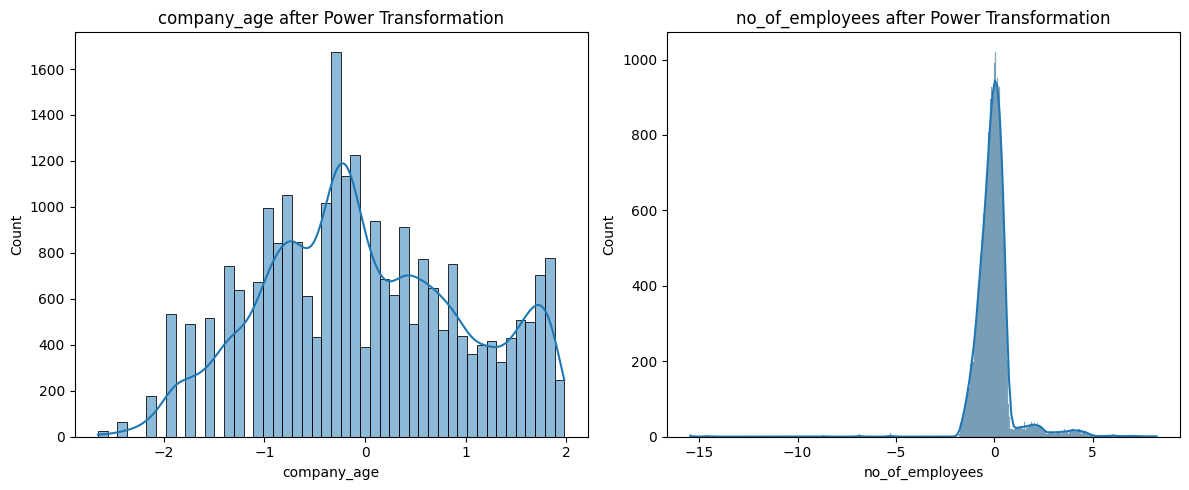

In [20]:
plt.figure(figsize=(12,5))
for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(X_copy[col], kde=True)
    plt.title(f'{col} after Power Transformation')
plt.tight_layout()
plt.show()

In [21]:
X_copy.skew(axis=0, skipna=True)

company_age        0.120823
no_of_employees    0.399339
dtype: float64

In [22]:
for feature in categorical_cols:
    print(feature,':', df[feature].nunique())

continent : 6
education_of_employee : 4
has_job_experience : 2
requires_job_training : 2
region_of_employment : 5
unit_of_wage : 4
full_time_position : 2
case_status : 2


### Feature Encoding and Scaling
**One Hot Encoding for Columns which had lesser unique values and not ordinal** <br>
<br>
- One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.<br>
<br>

**Ordinal Encoding for Columns which has many unique categories** <br>

- Ordinal encoding is used here as label encoder is supported for column transformer.<br>
- Ordinal encoding is used for Ordinal Variable. Variable comprises a finite set of discrete values with a ranked ordering between values.<br>
<br>

**Standard Scaler**

- Standardize features by removing the mean and scaling to unit variance.<br>
<br>

**Power Transformer** <br>

- Power transforms are a technique for transforming numerical input or output variables to have a Gaussian or more-Gaussian-like probability distribution.

In [23]:
num_cols = list(X.select_dtypes(exclude='object').columns)

num_cols

['no_of_employees', 'prevailing_wage', 'company_age']

### Preprocessing using column transformer

In [24]:
or_column = ['has_job_experience','requires_job_training','full_time_position','education_of_employee']
oh_column = ['continent', 'unit_of_wage','region_of_employment']
transform_columns = ['no_of_employees', 'company_age']

from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()
ordinal_encoder = OrdinalEncoder()

transform_pipe = Pipeline(steps=[
    ('transformer', PowerTransformer(method='yeo-johnson')),])

preprocessor = ColumnTransformer(transformers=[
    ("OneHotEncoder", oh_transformer, oh_column),
    ("OrdinalEncoder", ordinal_encoder, or_column),
    ("PowerTransformer", transform_pipe, transform_columns)
]
)

In [25]:
X = preprocessor.fit_transform(X)

In [26]:
X

array([[ 0.        ,  1.        ,  0.        , ...,  2.        ,
         1.51729976, -0.95850606],
       [ 0.        ,  1.        ,  0.        , ...,  3.        ,
         0.03091211, -0.47081562],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
         2.88507606, -1.08047911],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  3.        ,
        -0.41388512,  1.552921  ],
       [ 0.        ,  1.        ,  0.        , ...,  3.        ,
        -0.11194883,  1.68577154],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
         0.21874168,  1.03193666]])

## Classification

In [27]:
#handle imbalance in the target variable using SMOTEENN

from imblearn.combine import SMOTETomek, SMOTEENN

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTEENN(random_state=42,sampling_strategy='minority' )
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X, y)

## Train Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)   
X_train.shape, X_test.shape

((12982, 21), (3246, 21))

In [29]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [30]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted) # Calculate Accuracy
    f1 = f1_score(true, predicted) # Calculate F1-score
    precision = precision_score(true, predicted) # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [31]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
     "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()

}



In [32]:
def evaluate_models(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    
    models_list = []
    accuracy_list = []
    auc= []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training set performance
        model_train_accuracy, model_train_f1,model_train_precision,\
        model_train_recall,model_train_rocauc_score=evaluate_clf(y_train ,y_train_pred)


        # Test set performance
        model_test_accuracy,model_test_f1,model_test_precision,\
        model_test_recall,model_test_rocauc_score=evaluate_clf(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1)) 
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        auc.append(model_test_rocauc_score)
        print('='*35)
        print('\n')
        
    report=pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model Name', 'Accuracy']).sort_values(by=['Accuracy'], ascending=False)
        
    return report

## Model Training

In [33]:
base_model_report =evaluate_models(X=X_res, y=y_res, models=models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9646
- F1 score: 0.9634
- Precision: 0.9724
- Recall: 0.9546
- Roc Auc Score: 0.9643


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9421
- F1 score: 0.9402
- Precision: 0.9487
- Recall: 0.9319
- Roc Auc Score: 0.9419


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9032
- F1 score: 0.9010
- Precision: 0.8897
- Recall: 0.9126
- Roc Auc Score: 0.9035
----------------------------------
Model performance for Test set
- Accuracy: 0.8894
- F1 score: 0.8869
- Precision: 0.8866
- Recall: 0.8871
- Roc Auc Score: 0.8894


Logistic Regression
Model performance for Training 

In [34]:
base_model_report

,Model Name,Accuracy
0,Random Forest,0.964572
1,Decision Tree,0.942083
4,K-Neighbors Classifier,0.940542
5,XGBClassifier,0.932224
6,CatBoosting Classifier,0.928219
2,Gradient Boosting,0.889402
7,Support Vector Classifier,0.888170
8,AdaBoost Classifier,0.861368
3,Logistic Regression,0.733518


In [35]:
#Initialize few parameter for Hyperparamter tuning
xgboost_params = {
    'max_depth':range(3,10,2),
    'min_child_weight':range(1,6,2)
}

rf_params = {
    "max_depth": [10, 12, None, 15, 20],
    "max_features": ['sqrt', 'log2', None],
    "n_estimators": [10, 50, 100, 200]
}

knn_params = {
    "algorithm": ['auto', 'ball_tree', 'kd_tree','brute'],
    "weights": ['uniform', 'distance'],
    "n_neighbors": [3, 4, 5, 7, 9],
}

In [36]:

# Models list for Hyperparameter tuning
randomcv_models = [
    ('XGBoost', XGBClassifier(), xgboost_params),
    ("RF", RandomForestClassifier(), rf_params),
    ("KNN", KNeighborsClassifier(), knn_params)
]

Create a function for model training and report which can be used in hyperparameter tuning loop

In [37]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2, 
                                   n_jobs=-1)
    random.fit(X_res, y_res)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits
---------------- Best Params for XGBoost -------------------
{'min_child_weight': 1, 'max_depth': 9}
---------------- Best Params for RF -------------------
{'n_estimators': 200, 'max_features': 'log2', 'max_depth': None}
---------------- Best Params for KNN -------------------
{'weights': 'distance', 'n_neighbors': 3, 'algorithm': 'auto'}


In [38]:
model_param

{'XGBoost': {'min_child_weight': 1, 'max_depth': 9},
 'RF': {'n_estimators': 200, 'max_features': 'log2', 'max_depth': None},
 'KNN': {'weights': 'distance', 'n_neighbors': 3, 'algorithm': 'auto'}}

Retraining the model with best parameters

In [39]:
from sklearn.metrics import roc_auc_score,roc_curve
best_models = {
    "Random Forest Classifier": RandomForestClassifier(**model_param['RF']),
    "KNeighborsClassifier": KNeighborsClassifier(**model_param['KNN']),
    "XGBClassifier": XGBClassifier(**model_param['XGBoost'],n_jobs=-1),
}
tuned_report =evaluate_models(X=X_res, y=y_res, models=best_models)

Random Forest Classifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9646
- F1 score: 0.9635
- Precision: 0.9706
- Recall: 0.9565
- Roc Auc Score: 0.9644


KNeighborsClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9757
- F1 score: 0.9748
- Precision: 0.9846
- Recall: 0.9653
- Roc Auc Score: 0.9754


XGBClassifier
Model performance for Training set
- Accuracy: 0.9985
- F1 score: 0.9985
- Precision: 0.9984
- Recall: 0.9986
- Roc Auc Score: 0.9985
----------------------------------
Model performance for Test set
- Accuracy: 0.9513
- F1 score: 0.9497
- Precision: 0.9589
- Recall: 0.9407
- Roc Auc Score: 0.9511




In [40]:
print(model_param.keys())

dict_keys(['XGBoost', 'RF', 'KNN'])


In [41]:
tuned_report

,Model Name,Accuracy
1,KNeighborsClassifier,0.975662
0,Random Forest Classifier,0.964572
2,XGBClassifier,0.951325


In [42]:
best_model = KNeighborsClassifier(**model_param['KNN'])
best_model = best_model.fit(X_train,y_train)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print("FINAL MODEL 'KNN'")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

FINAL MODEL 'KNN'
Accuracy Score value: 0.9757
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1660
           1       0.98      0.97      0.97      1586

    accuracy                           0.98      3246
   macro avg       0.98      0.98      0.98      3246
weighted avg       0.98      0.98      0.98      3246



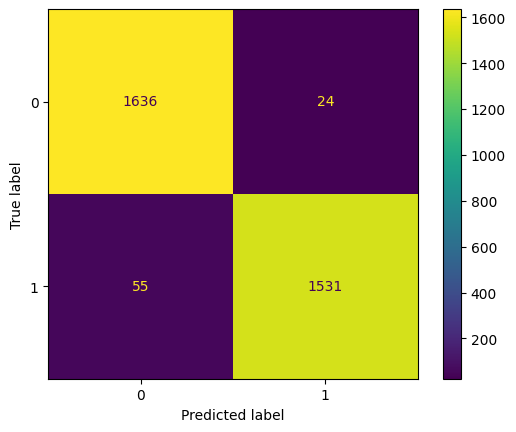

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

## Best Model is K-Nearest Neighbor(KNN) with Accuracy 97.56%